## Problem A
###A.1

In [23]:
import numpy as np

def sparse_data(s, N, d, seed=None):

    rng = np.random.default_rng(seed) ## Setting the range
    X = np.zeros((d, N), dtype=float) ## Generating d independent

    for i in range(d):
        support = rng.choice(N, size=s, replace=False)     # choose s distinct indices
        X[i, support] = rng.standard_normal(s)             # fill with N(0,1)

    return X

##A.2

In [24]:
X = sparse_data(s=4, N=10, d=5, seed=0)   # seed used only to make the output reproducible
print(X)

[[ 0.          0.         -0.53566937  0.          0.36159505  1.30400005
   0.          0.94708096  0.          0.        ]
 [-0.21879166  0.          0.          0.          0.04132598 -2.32503077
   0.          0.          0.         -1.24591095]
 [ 1.04251337  1.36646347  0.          0.          0.         -0.66519467
   0.          0.         -0.12853466  0.        ]
 [ 0.          0.         -0.92172538  0.         -0.74349925  0.22019512
   0.          0.          0.         -0.45772583]
 [ 0.          0.          0.         -0.12961363  0.         -0.65382861
   0.21465912  0.35537271  0.          0.        ]]


##A.3

In [25]:
import numpy as np

def MP(A, y, K): ## Matching Pursuit

    A = np.asarray(A, dtype=float) # measurement matrix (assumed columns have unit 2-norm)
    y = np.asarray(y, dtype=float).reshape(-1) # measurement vector

    m, N = A.shape
    x = np.zeros(N, dtype=float)

    X = np.zeros((N, K + 1), dtype=float)
    X[:, 0] = x

    for k in range(K): # K is number of iteration
        r = y - A @ x                              # residual
        corr = A.T @ r                             # correlations a_j^T r
        j = int(np.argmax(np.abs(corr)))           # maximize |a_j^T r|
        x[j] += corr[j]                            # x_{k+1} = x_k + (a_j^T r) e_j
        X[:, k + 1] = x

    return X


##A.4

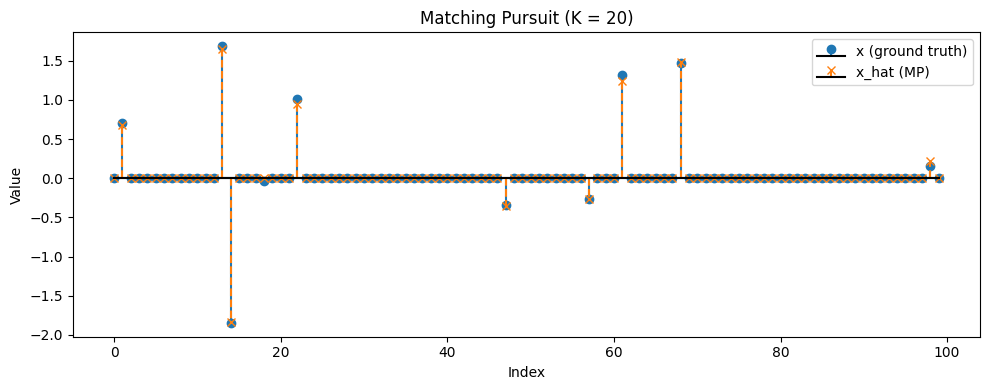

Relative error ||x - x_hat||_2 / ||x||_2 = 0.03666076133480488


In [26]:
import numpy as np
import matplotlib.pyplot as plt

# Load data
A = np.load("sparse_A.npy")
y = np.load("sparse_y.npy")
x = np.load("sparse_x.npy").reshape(-1)

# Sparsity level and iterations
s = int(np.count_nonzero(x))
K = 2 * s

# Run the Matching Pursuit
X = MP(A, y, K)
x_hat = X[:, -1]

# Plot ground truth vs MP estimate
plt.figure(figsize=(10, 4))
plt.stem(x, linefmt='C0-', markerfmt='C0o', basefmt='k-', label='x (ground truth)')
plt.stem(x_hat, linefmt='C1--', markerfmt='C1x', basefmt='k-', label='x_hat (MP)')
plt.xlabel("Index")
plt.ylabel("Value")
plt.title(f"Matching Pursuit (K = {K})")
plt.legend()
plt.tight_layout()
plt.show()

# Relative 2-norm error
rel_err = np.linalg.norm(x - x_hat, 2) / np.linalg.norm(x, 2)
print("Relative error ||x - x_hat||_2 / ||x||_2 =", rel_err)


##A.5

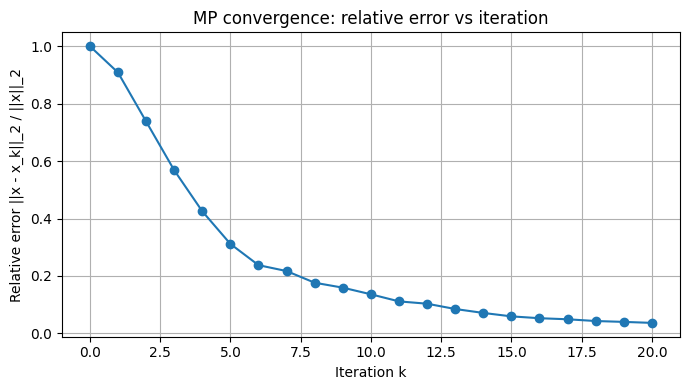

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# Load data
A = np.load("sparse_A.npy")
y = np.load("sparse_y.npy")
x = np.load("sparse_x.npy").reshape(-1)

s = int(np.count_nonzero(x))
K = 2 * s

# Run the Matching Pursuit
X = MP(A, y, K)

# Relative error at each iteration k
x_norm = np.linalg.norm(x, 2)
rel_errors = np.zeros(K + 1)

for k in range(K + 1):
    xk = X[:, k]
    rel_errors[k] = np.linalg.norm(x - xk, 2) / x_norm

# Plot error vs iteration
plt.figure(figsize=(7, 4))
plt.plot(range(K + 1), rel_errors, marker='o')
plt.xlabel("Iteration k")
plt.ylabel("Relative error ||x - x_k||_2 / ||x||_2")
plt.title("MP convergence: relative error vs iteration")
plt.grid(True)
plt.tight_layout()
plt.show()


I observe that the relative error is considerably decreasing the more iteration we have.

##A.6

In [28]:
import numpy as np

def OMP(A, y, K): # Orthogonal Matching Pursuit
    """
    Orthogonal Matching Pursuit (OMP) algorithm for sparse coding.
    The output is the following:
      X: (N, K+1) matrix whose columns are x_0, x_1, ..., x_K
    """
    A = np.asarray(A, dtype=float)
    y = np.asarray(y, dtype=float).reshape(-1)

    m, N = A.shape
    x = np.zeros(N, dtype=float)
    X = np.zeros((N, K + 1), dtype=float)
    X[:, 0] = x

    S = []  # support set (list of selected indices)

    for k in range(K):
        r = y - A @ x                            # residual
        corr = A.T @ r                          # correlations
        j = int(np.argmax(np.abs(corr)))        # best matching index

        if j not in S:
            S.append(j)

        # Restrict A to selected columns
        A_S = A[:, S]

        # Least squares solution
        z, _, _, _ = np.linalg.lstsq(A_S, y, rcond=None)

        # Update x
        x = np.zeros(N, dtype=float)
        x[S] = z

        X[:, k + 1] = x

    return X


##A.7

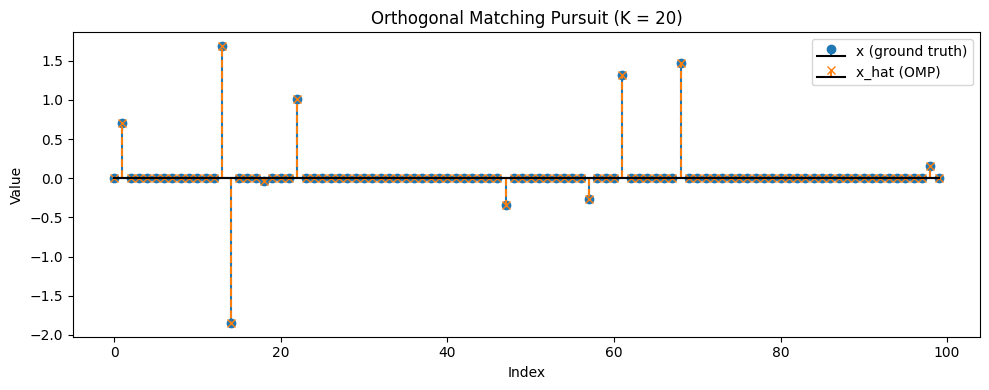

Relative error ||x - x_hat||_2 / ||x||_2 = 1.7441497888793515e-15


In [29]:
import numpy as np
import matplotlib.pyplot as plt

# Load data
A = np.load("sparse_A.npy")
y = np.load("sparse_y.npy")
x = np.load("sparse_x.npy").reshape(-1)

# Sparsity level and iterations
s = int(np.count_nonzero(x))
K = 2 * s

# Run OMP
X = OMP(A, y, K)
x_hat = X[:, -1]

# Plot ground truth vs OMP estimate
plt.figure(figsize=(10, 4))
plt.stem(x, linefmt='C0-', markerfmt='C0o', basefmt='k-', label='x (ground truth)')
plt.stem(x_hat, linefmt='C1--', markerfmt='C1x', basefmt='k-', label='x_hat (OMP)')
plt.xlabel("Index")
plt.ylabel("Value")
plt.title(f"Orthogonal Matching Pursuit (K = {K})")
plt.legend()
plt.tight_layout()
plt.show()

# Relative 2-norm error
rel_err = np.linalg.norm(x - x_hat, 2) / np.linalg.norm(x, 2)
print("Relative error ||x - x_hat||_2 / ||x||_2 =", rel_err)


##A.8


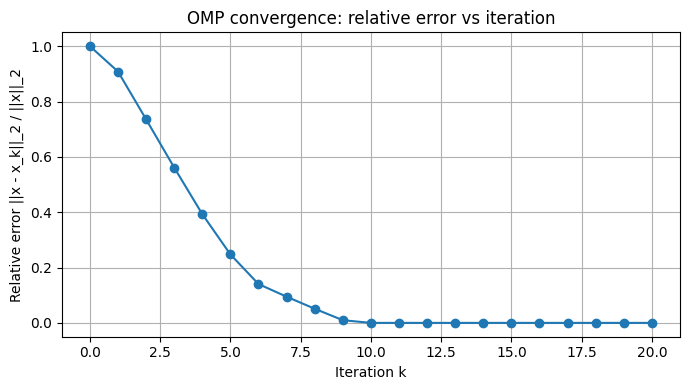

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# Load data
A = np.load("sparse_A.npy")
y = np.load("sparse_y.npy")
x = np.load("sparse_x.npy").reshape(-1)

s = int(np.count_nonzero(x))
K = 2 * s

# Run OMP
X = OMP(A, y, K)

# Relative error at each iteration k
x_norm = np.linalg.norm(x, 2)
rel_errors = np.zeros(K + 1)

for k in range(K + 1):
    xk = X[:, k]
    rel_errors[k] = np.linalg.norm(x - xk, 2) / x_norm

# Plot error vs iteration
plt.figure(figsize=(7, 4))
plt.plot(range(K + 1), rel_errors, marker='o')
plt.xlabel("Iteration k")
plt.ylabel("Relative error ||x - x_k||_2 / ||x||_2")
plt.title("OMP convergence: relative error vs iteration")
plt.grid(True)
plt.tight_layout()
plt.show()


The OMP method is performing better than the MP method because, after the tenth iteration, the relative error drops to zero. Even though the MP method improves as more iterations are added, after the twentieth iteration it does not reach zero.

## Problem B
### B.1

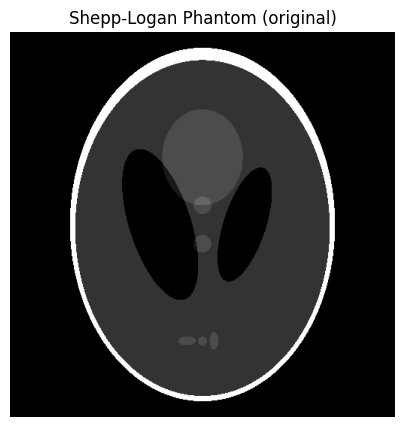

In [31]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np

# Load image
raw_image = mpimg.imread("image_phantom.bmp")

#converting to grayscale for display if the image has 3 channels
if raw_image.ndim == 3:
    img = raw_image[..., :3].mean(axis=2)
else:
    img = raw_image

# Plotting it
plt.figure(figsize=(5, 5))
plt.imshow(img, cmap="gray")
plt.axis("off")
plt.title("Shepp-Logan Phantom (original)")
plt.show()


### B.2

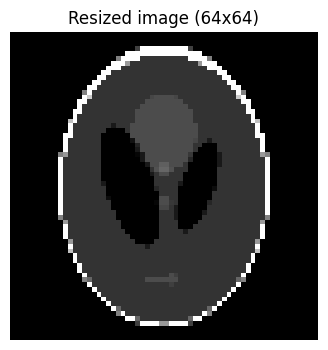

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from skimage.transform import resize

# Load image
raw_image = mpimg.imread("image_phantom.bmp")

# Convert to grayscale if needed
if raw_image.ndim == 3:
    img_gray = raw_image[..., :3].mean(axis=2)
else:
    img_gray = raw_image

# Resize to 64x64
img = resize(img_gray, (64, 64), anti_aliasing=False, preserve_range=True).astype(float)

# Visualize resized image
plt.figure(figsize=(4, 4))
plt.imshow(img, cmap="gray")
plt.axis("off")
plt.title("Resized image (64x64)")
plt.show()


### B.3

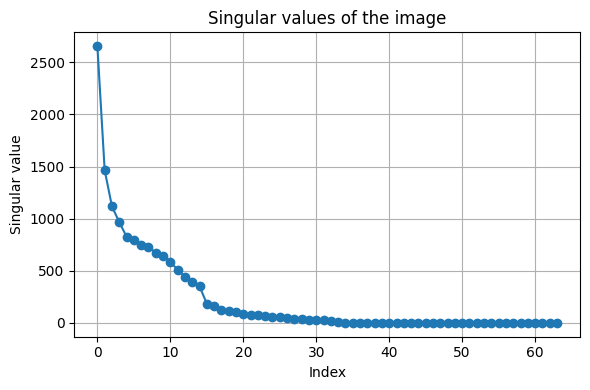

In [33]:
import numpy as np
import matplotlib.pyplot as plt

# Compute SVD of the resized image img
U, S, Vt = np.linalg.svd(img, full_matrices=False)

# Plot singular values
plt.figure(figsize=(6, 4))
plt.plot(S, marker='o')
plt.xlabel("Index")
plt.ylabel("Singular value")
plt.title("Singular values of the image")
plt.grid(True)
plt.tight_layout()
plt.show()


The singular values decrease as the index increases, indicating that most of the image energy is concentrated in the first few singular components.

### B.4

k needed for 95% variance: 12


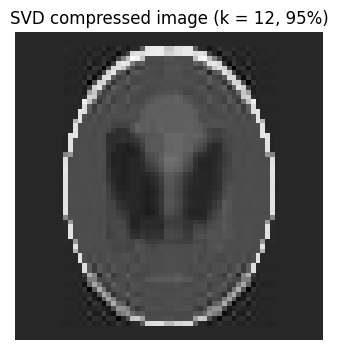

In [34]:
import numpy as np
import matplotlib.pyplot as plt

# SVD of img (assumes img already exists from Q2)
U, S, Vt = np.linalg.svd(img, full_matrices=False)

# Find smallest k such that 95% of variance/energy is explained
energy = S**2
cum_energy_ratio = np.cumsum(energy) / np.sum(energy)
k95 = int(np.searchsorted(cum_energy_ratio, 0.95) + 1)

print("k needed for 95% variance:", k95)

# Reconstruct compressed image using rank-k95 approximation
img_k = (U[:, :k95] * S[:k95]) @ Vt[:k95, :]

# Plot compressed image
plt.figure(figsize=(4, 4))
plt.imshow(img_k, cmap="gray")
plt.axis("off")
plt.title(f"SVD compressed image (k = {k95}, 95%)")
plt.show()



We need 25 singular values for that.

### B.5

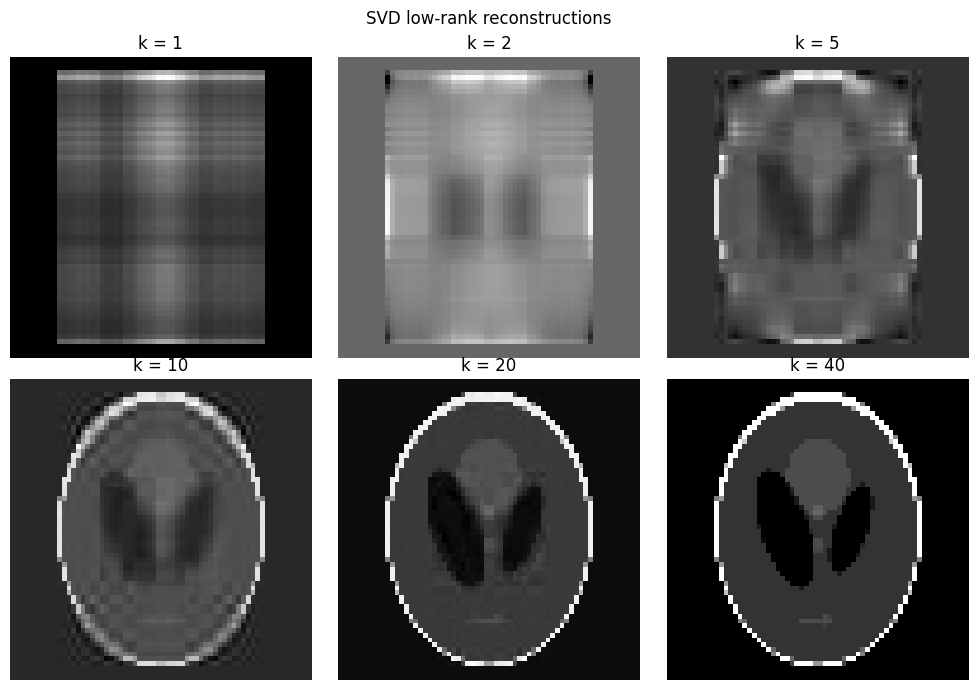

In [35]:
import numpy as np
import matplotlib.pyplot as plt

# SVD of image
U, S, Vt = np.linalg.svd(img, full_matrices=False)

# Choose k values
k_list = [1, 2, 5, 10, 20, 40]

# Plot reconstructions
fig, axes = plt.subplots(2, 3, figsize=(10, 7))
axes = axes.ravel()

for ax, k in zip(axes, k_list):
    img_k = (U[:, :k] * S[:k]) @ Vt[:k, :]
    ax.imshow(img_k, cmap="gray")
    ax.set_title(f"k = {k}")
    ax.axis("off")

plt.suptitle("SVD low-rank reconstructions")
plt.tight_layout()
plt.show()


### B.6

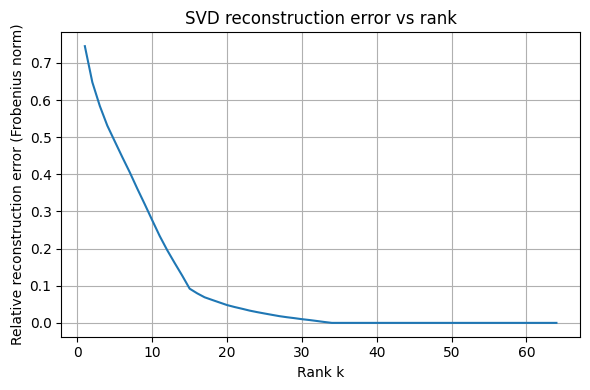

In [36]:
import numpy as np
import matplotlib.pyplot as plt

# SVD of img
U, S, Vt = np.linalg.svd(img, full_matrices=False)

# Compute relative reconstruction error for increasing k
max_k = min(img.shape)
errors = []

img_norm = np.linalg.norm(img, 'fro')

for k in range(1, max_k + 1):
    img_k = (U[:, :k] * S[:k]) @ Vt[:k, :]
    err = np.linalg.norm(img - img_k, 'fro') / img_norm
    errors.append(err)

# Plot reconstruction error vs k
plt.figure(figsize=(6, 4))
plt.plot(range(1, max_k + 1), errors)
plt.xlabel("Rank k")
plt.ylabel("Relative reconstruction error (Frobenius norm)")
plt.title("SVD reconstruction error vs rank")
plt.grid(True)
plt.tight_layout()
plt.show()


### B.7

In [37]:
import numpy as np
# Convert a full Haar wavelet decomposition (as returned by pywt.wavedec2) into a 2D array
def from_deco_to_img(wave_deco):

    L = len(wave_deco) - 1                 # number of detail levels
    n = 2 ** L                             # image size (assumes full decomposition to 1x1)
    deco_img = np.zeros((n, n), dtype=float)

    # scaling coefficient at (0,0)
    cA = wave_deco[0]
    deco_img[0, 0] = float(cA[0, 0]) if np.ndim(cA) == 2 else float(cA)

    # place details level-by-level
    for i in range(1, L + 1):
        cH, cV, cD = wave_deco[i]          # each should be (2^(i-1), 2^(i-1))
        s = 2 ** (i - 1)

        deco_img[0:s,     s:2*s]   = cH    # horizontal detail
        deco_img[s:2*s,   0:s]     = cV    # vertical detail
        deco_img[s:2*s,   s:2*s]   = cD    # diagonal detail

    return deco_img


### B.8

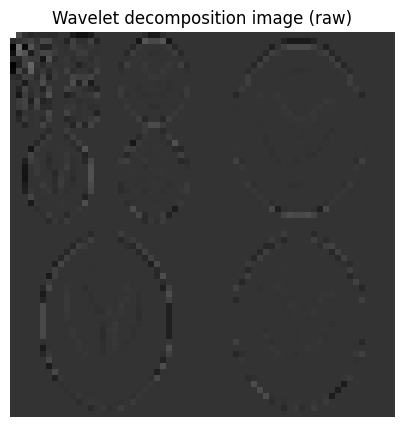

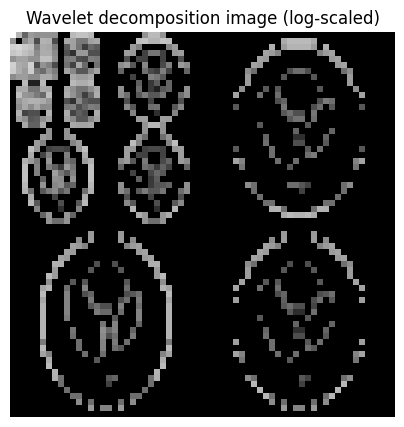

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import pywt

# Wavelet decomposition that was incremented in the previous questions
wave_deco = pywt.wavedec2(img, 'haar', mode='symmetric', axes=(-2, -1))

# Convert decomposition to image
deco_img = from_deco_to_img(wave_deco)

# Visualize deco_img
plt.figure(figsize=(5, 5))
plt.imshow(deco_img, cmap='gray')
plt.axis("off")
plt.title("Wavelet decomposition image (raw)")
plt.show()

# Enhanced visibility using log transform
plt.figure(figsize=(5, 5))
plt.imshow(np.log1p(np.abs(deco_img)), cmap='gray')
plt.axis("off")
plt.title("Wavelet decomposition image (log-scaled)")
plt.show()


### B.9

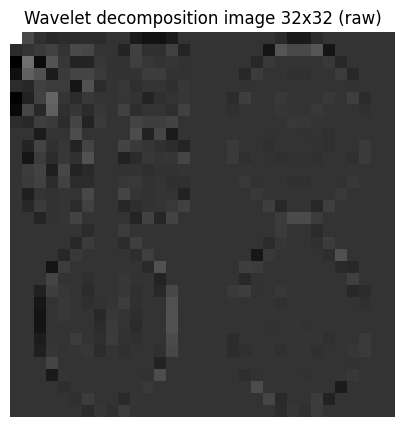

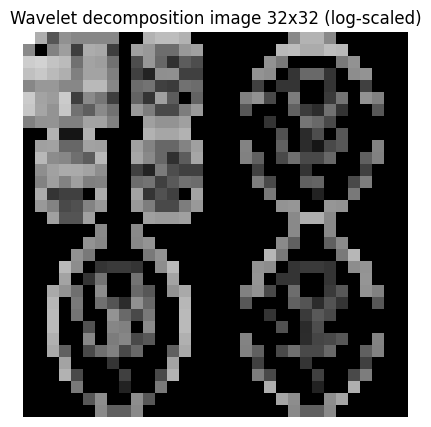

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import pywt
from skimage.transform import resize

# Create a 32x32 version of img (no anti-aliasing)
img32 = resize(img, (32, 32), anti_aliasing=False, preserve_range=True).astype(float)

# Wavelet decomposition on 32x32 image
wave_deco_32 = pywt.wavedec2(img32, 'haar', mode='symmetric', axes=(-2, -1))

# Convert decomposition to image
deco_img_32 = from_deco_to_img(wave_deco_32)

# Visualize deco_img_32
plt.figure(figsize=(5, 5))
plt.imshow(deco_img_32, cmap='gray')
plt.axis("off")
plt.title("Wavelet decomposition image 32x32 (raw)")
plt.show()

# Enhanced visibility using log transform
plt.figure(figsize=(5, 5))
plt.imshow(np.log1p(np.abs(deco_img_32)), cmap='gray')
plt.axis("off")
plt.title("Wavelet decomposition image 32x32 (log-scaled)")
plt.show()


### B.10


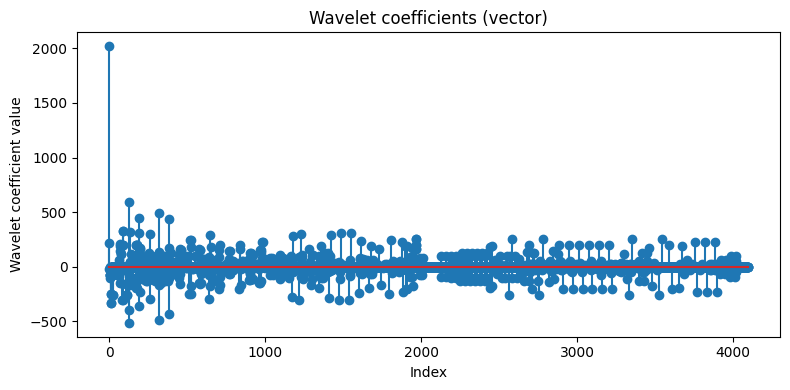

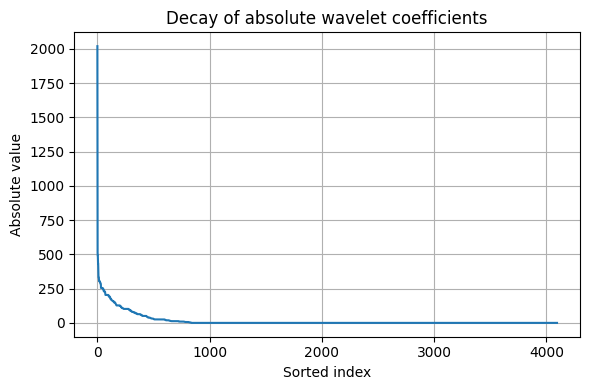

In [42]:
plt.figure(figsize=(8, 4))
plt.stem(deco_vec)
plt.xlabel("Index")
plt.ylabel("Wavelet coefficient value")
plt.title("Wavelet coefficients (vector)")
plt.tight_layout()
plt.show()

# Absolute coefficients sorted in descending order
abs_sorted = np.sort(np.abs(deco_vec))[::-1]

plt.figure(figsize=(6, 4))
plt.plot(abs_sorted)
plt.xlabel("Sorted index")
plt.ylabel("Absolute value")
plt.title("Decay of absolute wavelet coefficients")
plt.grid(True)
plt.tight_layout()
plt.show()


Since the absolute wavelet coefficients decay quickly, the image can be well approximated using only the largest coefficients, which justifies the effectiveness of wavelet compression methods such as JPEG 2000.

### B.11

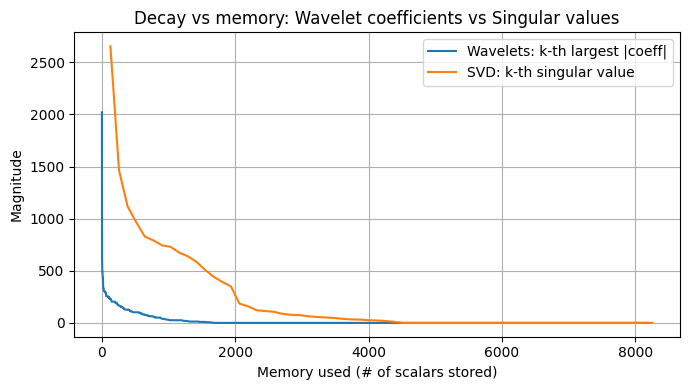

In [43]:
import numpy as np
import matplotlib.pyplot as plt

abs_wave = np.sort(np.abs(deco_vec))[::-1]          # k-th largest absolute wavelet coeff
k_max_wave = len(abs_wave)
mem_wave = 2 * np.arange(1, k_max_wave + 1)         # store k coeffs + k positions => 2k scalars

#SVD side
n, m = img.shape
k_max_svd = len(S)

# Memory for rank-k SVD
mem_svd = (n * np.arange(1, k_max_svd + 1)) + (m * np.arange(1, k_max_svd + 1)) + np.arange(1, k_max_svd + 1)

# --- Plot comparison ---
plt.figure(figsize=(7, 4))

# Wavelet: plot kth largest |coeff| vs memory
plt.plot(mem_wave, abs_wave, label="Wavelets: k-th largest |coeff|")

# SVD: plot kth singular value vs memory
plt.plot(mem_svd, S, label="SVD: k-th singular value")

plt.xlabel("Memory used (# of scalars stored)")
plt.ylabel("Magnitude")
plt.title("Decay vs memory: Wavelet coefficients vs Singular values")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


Wavelet compression is more memory efficient because the absolute wavelet coefficients decay faster with memory usage than the singular values. This allows most of the image information to be captured using fewer stored scalars compared to SVD.

##Problem C
### C.1

In [45]:
import pandas as pd

df_train = pd.read_csv("house_train.csv")
df_train.head()


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


### C.2

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Basic overview ---
print("Shape of dataset:", df_train.shape)
print("\nData types:")
print(df_train.dtypes.value_counts())

# Count numerical vs categorical features
num_cols = df_train.select_dtypes(include=[np.number]).columns
cat_cols = df_train.select_dtypes(exclude=[np.number]).columns

print("\nNumber of numerical features:", len(num_cols))
print("Number of categorical features:", len(cat_cols))

# --- Missing values ---
missing_counts = df_train.isnull().sum()
missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False)

missing_percent = 100 * missing_counts / len(df_train)

missing_df = pd.DataFrame({
    "MissingCount": missing_counts,
    "MissingPercent": missing_percent
})

print("\nColumns with missing values:")
print(missing_df)


Shape of dataset: (1449, 81)

Data types:
object     43
int64      35
float64     3
Name: count, dtype: int64

Number of numerical features: 38
Number of categorical features: 43

Columns with missing values:
              MissingCount  MissingPercent
PoolQC                1442       99.516908
MiscFeature           1396       96.342305
Alley                 1359       93.788820
Fence                 1170       80.745342
MasVnrType             864       59.627329
FireplaceQu            683       47.135956
LotFrontage            259       17.874396
GarageType              78        5.383023
GarageYrBlt             78        5.383023
GarageFinish            78        5.383023
GarageQual              78        5.383023
GarageCond              78        5.383023
BsmtExposure            38        2.622498
BsmtFinType2            38        2.622498
BsmtQual                37        2.553485
BsmtCond                37        2.553485
BsmtFinType1            37        2.553485
MasVnrArea       

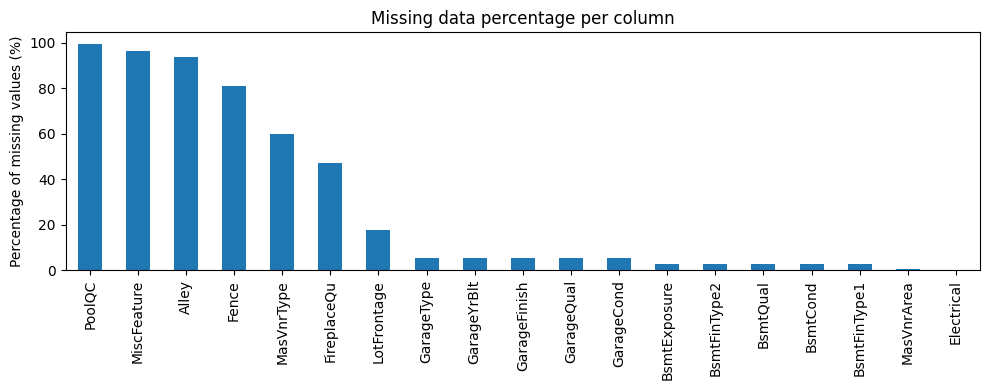

In [49]:
# --- Visualization: missing data percentage ---
plt.figure(figsize=(10, 4))
missing_percent.plot(kind="bar")
plt.ylabel("Percentage of missing values (%)")
plt.title("Missing data percentage per column")
plt.tight_layout()
plt.show()

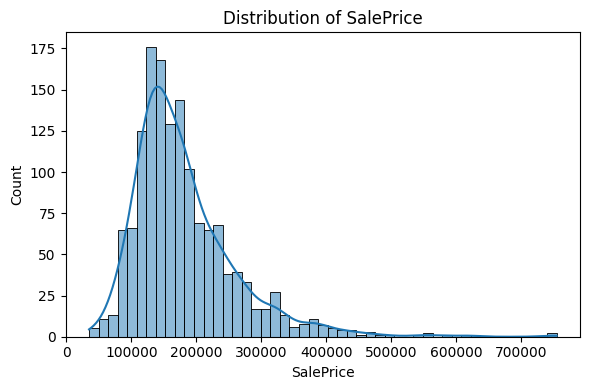

In [50]:
# --- Visualization: SalePrice distribution ---
plt.figure(figsize=(6, 4))
sns.histplot(df_train["SalePrice"], kde=True)
plt.title("Distribution of SalePrice")
plt.tight_layout()
plt.show()

The dataset contains both numerical and categorical variables, with several features exhibiting missing values. Some missing values likely correspond to the absence of a feature, while others require imputation. Additionally, many numerical variables, including SalePrice, show skewed distributions, suggesting that transformations may be beneficial for modeling.

### C.3


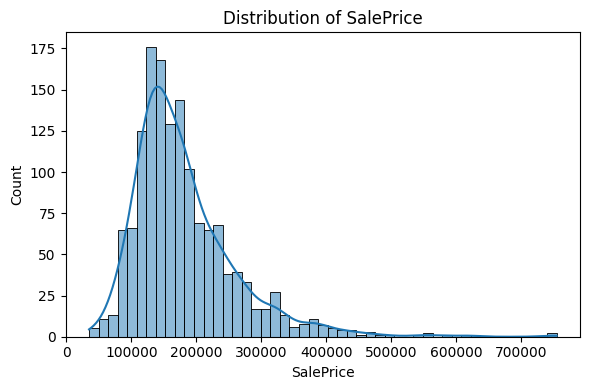

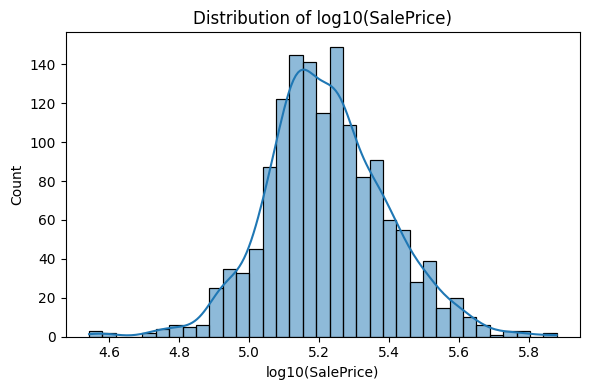

In [51]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of SalePrice
plt.figure(figsize=(6, 4))
sns.histplot(df_train["SalePrice"], kde=True)
plt.xlabel("SalePrice")
plt.title("Distribution of SalePrice")
plt.tight_layout()
plt.show()

# Log10 transformation
df_train["SalePriceLog"] = np.log10(df_train["SalePrice"])

# Distribution after log transformation
plt.figure(figsize=(6, 4))
sns.histplot(df_train["SalePriceLog"], kde=True)
plt.xlabel("log10(SalePrice)")
plt.title("Distribution of log10(SalePrice)")
plt.tight_layout()
plt.show()


The log transformation reduces the strong right skew of SalePrice, making the distribution more symmetric and closer to normal. This is not only for readability, but also improves model assumptions, reduces the influence of outliers, and facilitates linear modeling.

### C.4

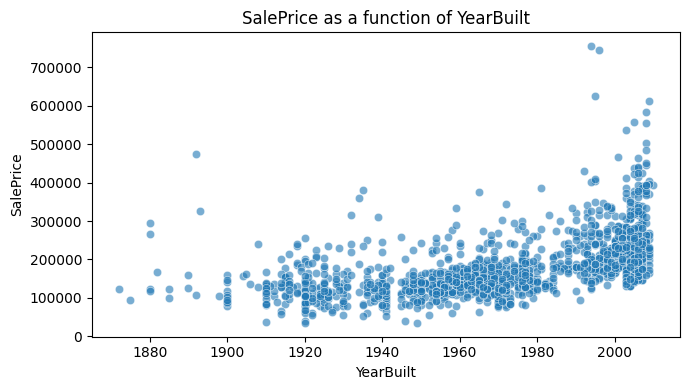

In [53]:
## Plot SalePrice as a function of YearBuilt
import matplotlib.pyplot as plt
import seaborn as sns

# Scatter plot of SalePrice vs YearBuilt
plt.figure(figsize=(7, 4))
sns.scatterplot(
    x=df_train["YearBuilt"],
    y=df_train["SalePrice"],
    alpha=0.6
)

plt.xlabel("YearBuilt")
plt.ylabel("SalePrice")
plt.title("SalePrice as a function of YearBuilt")
plt.tight_layout()
plt.show()


We have more value in the laters years, and we see that we have missing values espacially before 1920.

### C.5

In [54]:
import pandas as pd
import numpy as np

# Columns to include
cols = ["MSSubClass", "YearBuilt", "YearRemodAdd", "GarageType", "Fence", "SaleCondition"]

# Separate numerical and categorical columns
num_cols = ["MSSubClass", "YearBuilt", "YearRemodAdd"]
cat_cols = ["GarageType", "Fence", "SaleCondition"]

# Group by MSZoning
df_by_zone = df_train.groupby("MSZoning").agg(
    {
        "MSSubClass": "mean",
        "YearBuilt": "mean",
        "YearRemodAdd": "mean",
        "GarageType": lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan,
        "Fence": lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan,
        "SaleCondition": lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan,
    }
)

# Print result
df_by_zone


,MSSubClass,YearBuilt,YearRemodAdd,GarageType,Fence,SaleCondition
MSZoning,,,,,,
C (all),56.000000,1924.100000,1958.200000,Detchd,MnPrv,Abnorml
FV,91.562500,2004.515625,2004.828125,Attchd,GdWo,Normal
RH,80.312500,1945.687500,1971.937500,Detchd,MnPrv,Normal
RL,49.440070,1975.446194,1985.608049,Attchd,MnPrv,Normal
RM,84.050926,1942.847222,1976.796296,Detchd,MnPrv,Normal


### C.6

In [55]:
import numpy as np
import pandas as pd

# Create a copy of the training data
df_train_filled = df_train.copy()

# Fill categorical features first then the numerical ones
# Missing values indicate absence of the feature
cat_fill_none = ["PoolQC", "MiscFeature", "Alley", "Fence", "FireplaceQu", "GarageType"]
for col in cat_fill_none:
    if col in df_train_filled.columns:
        df_train_filled[col] = df_train_filled[col].fillna("None")
#numerical features
# LotFrontage: use median
if "LotFrontage" in df_train_filled.columns:
    df_train_filled["LotFrontage"] = df_train_filled["LotFrontage"].fillna(
        df_train_filled["LotFrontage"].median()
    )

# GarageYrBlt
if "GarageYrBlt" in df_train_filled.columns:
    df_train_filled["GarageYrBlt"] = df_train_filled["GarageYrBlt"].fillna(
        df_train_filled["YearBuilt"]
    )

# MasVnrArea: missing means no masonry veneer
if "MasVnrArea" in df_train_filled.columns:
    df_train_filled["MasVnrArea"] = df_train_filled["MasVnrArea"].fillna(0)

# Display requested values
cols_to_show = ["PoolQC", "MiscFeature", "LotFrontage", "GarageYrBlt", "MasVnrArea"]
df_train_filled.loc[[234, 287], cols_to_show]


,PoolQC,MiscFeature,LotFrontage,GarageYrBlt,MasVnrArea
234,None,None,70.0,2002.0,0.0
287,None,None,70.0,1971.0,0.0


### C.7


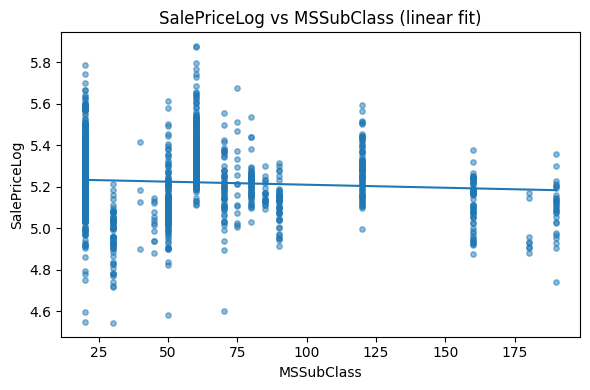

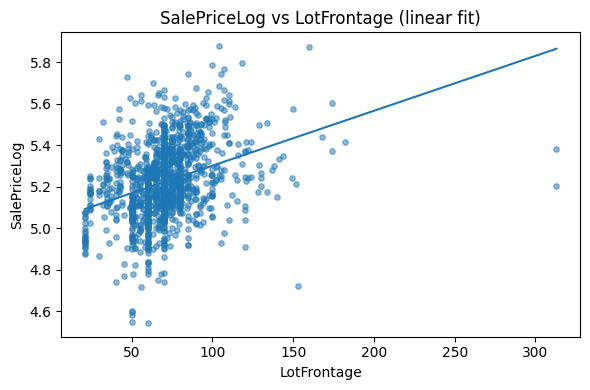

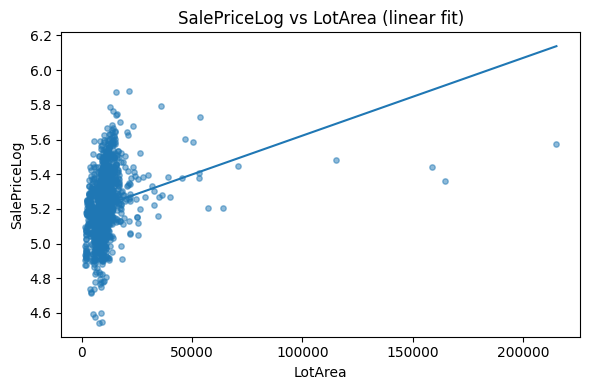

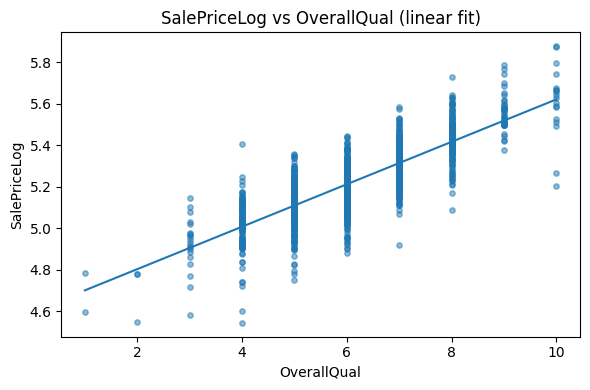

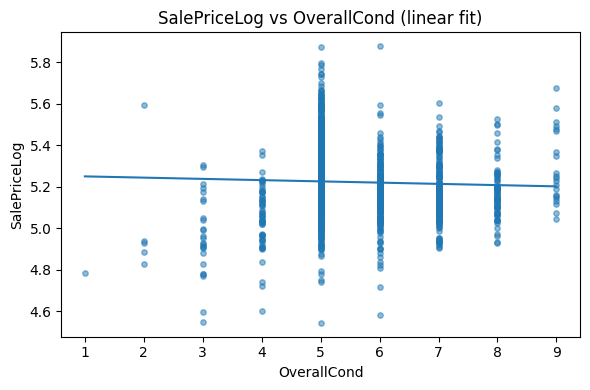

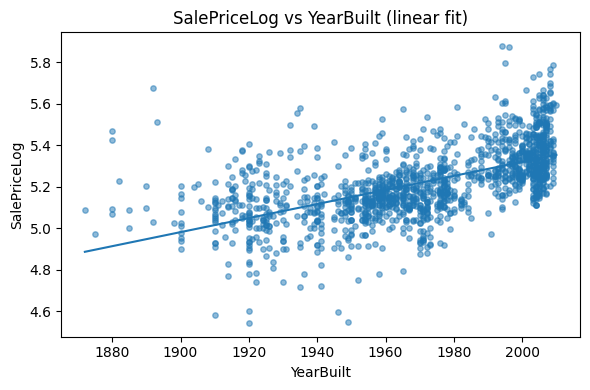

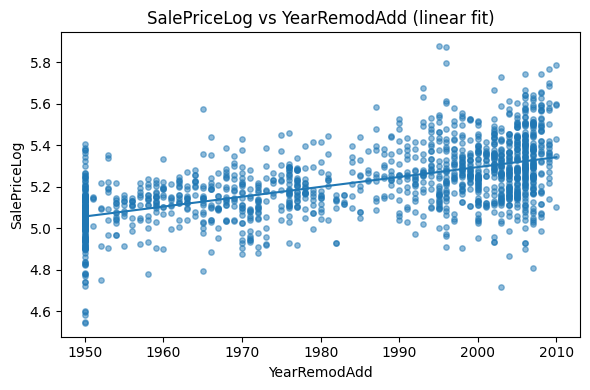

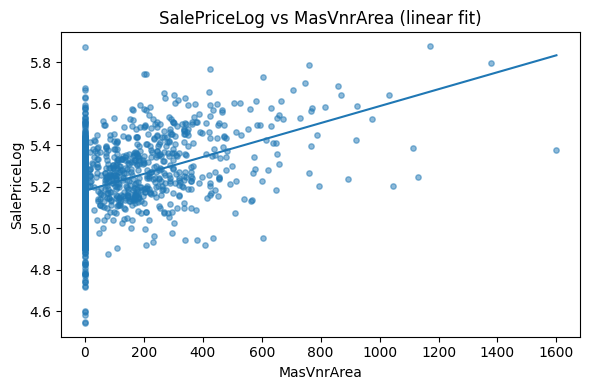

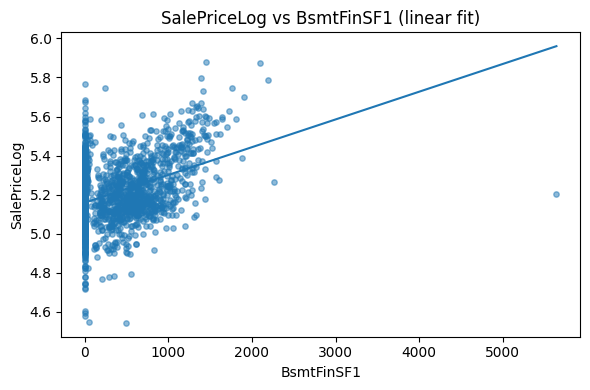

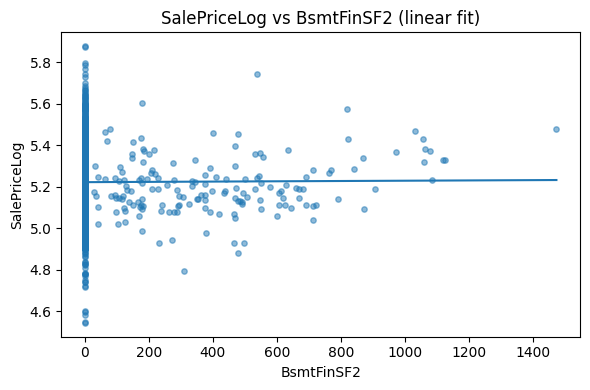

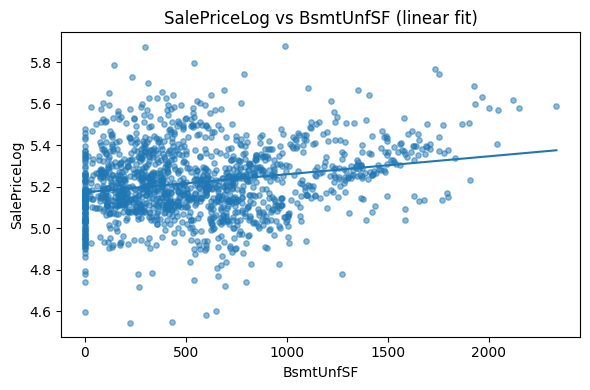

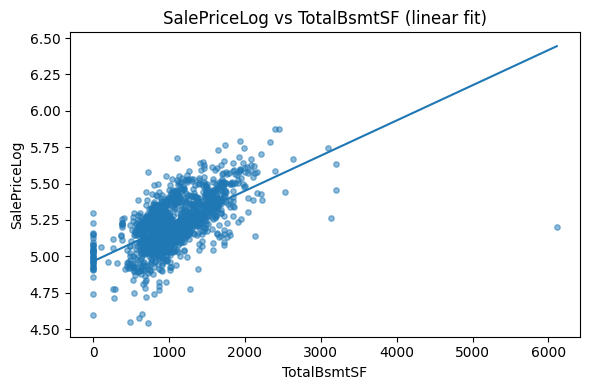

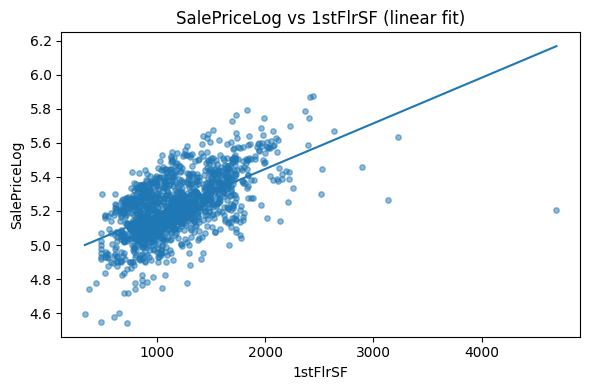

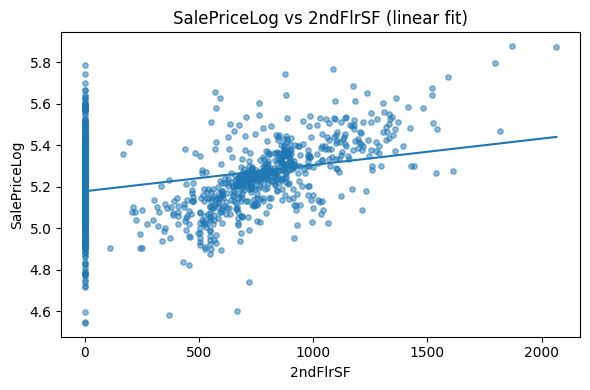

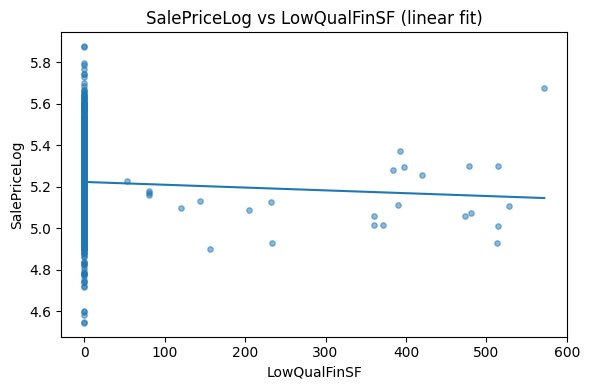

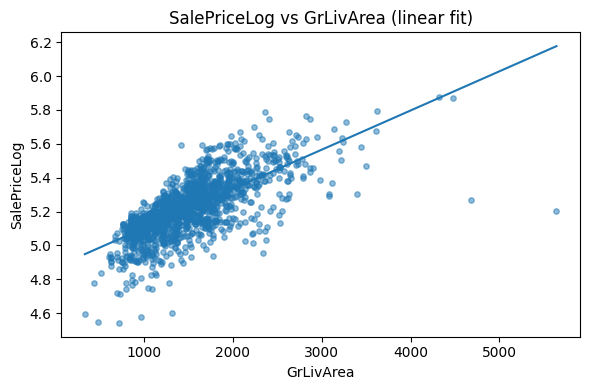

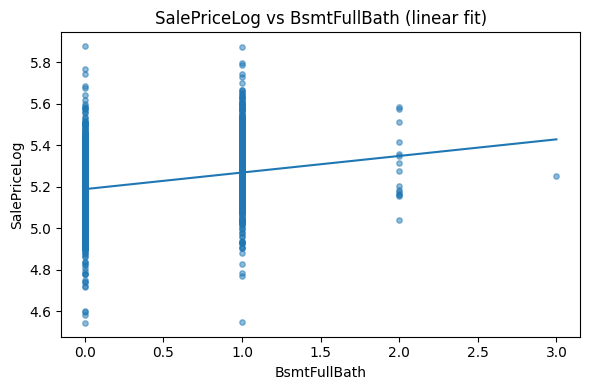

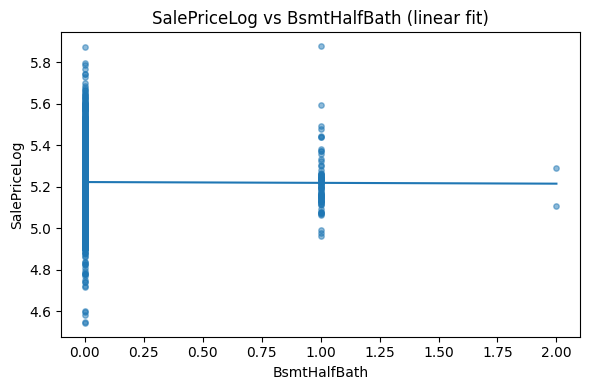

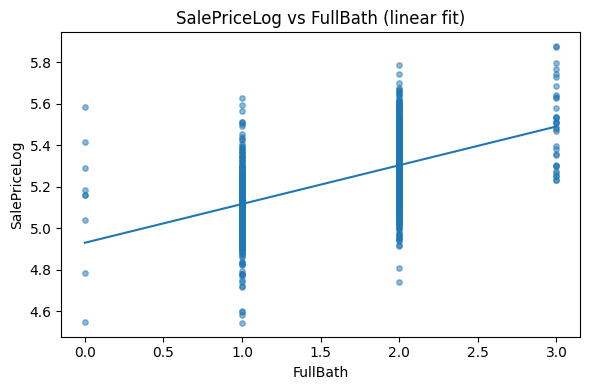

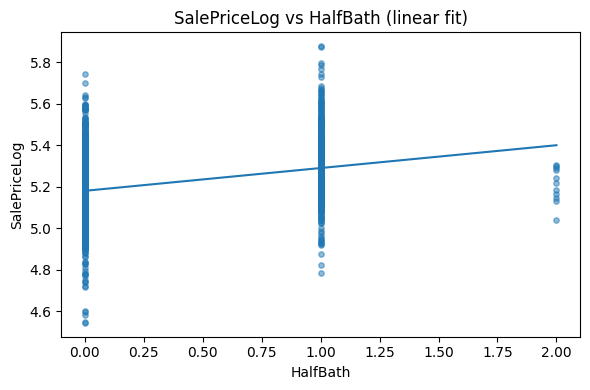

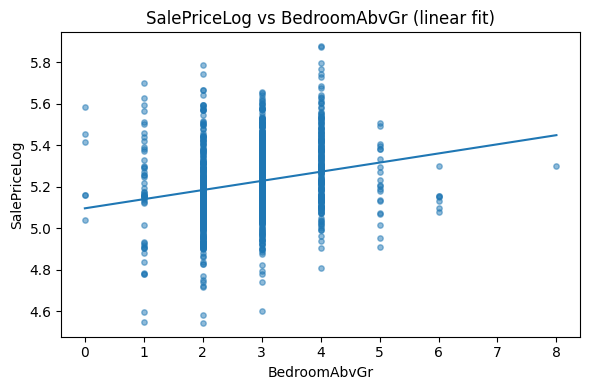

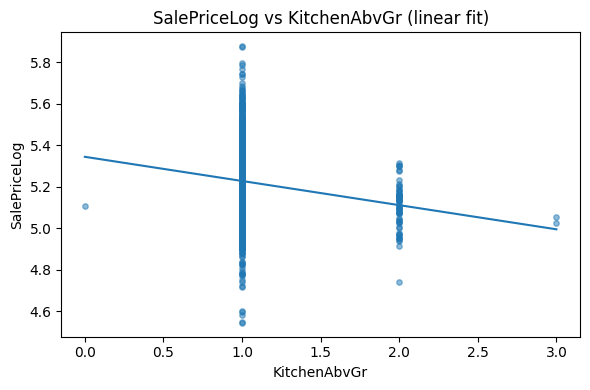

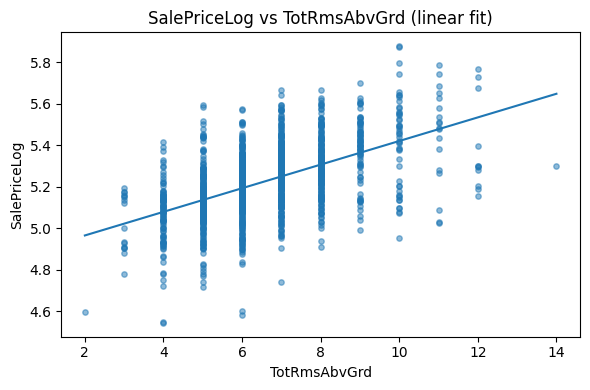

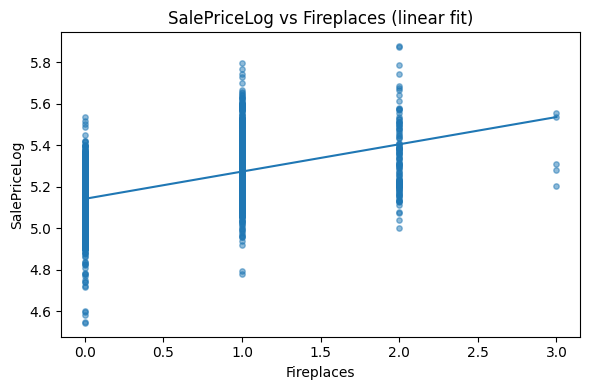

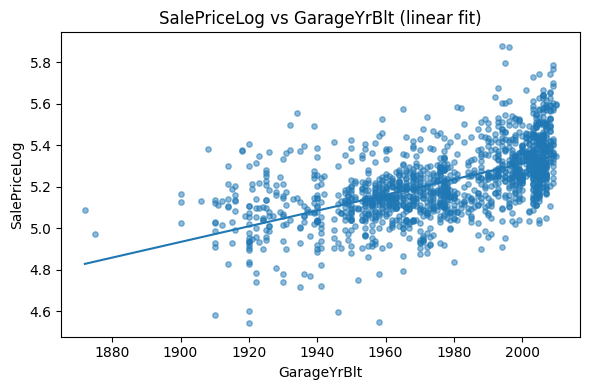

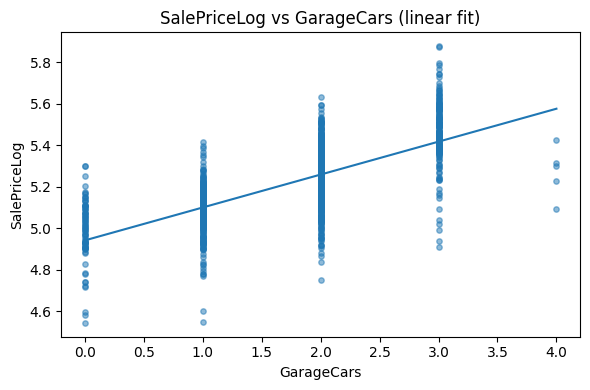

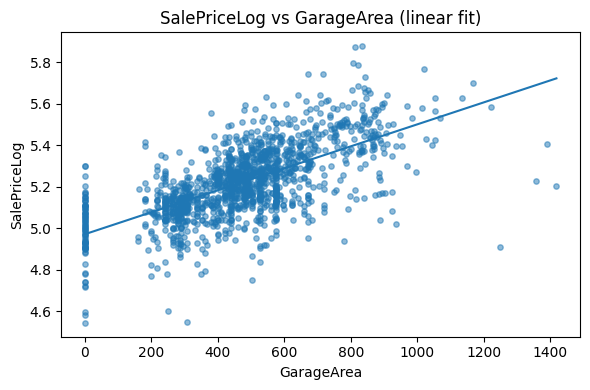

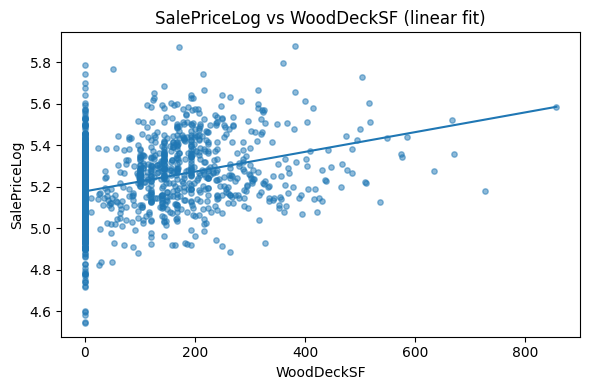

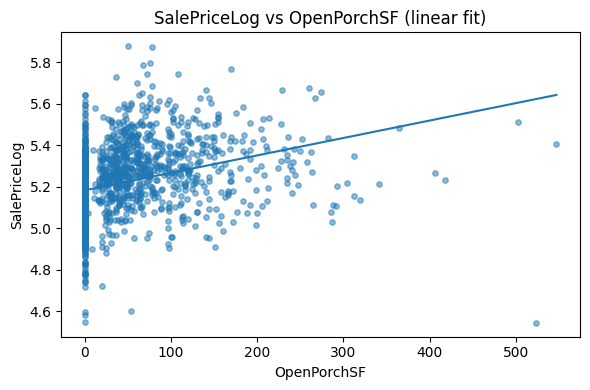

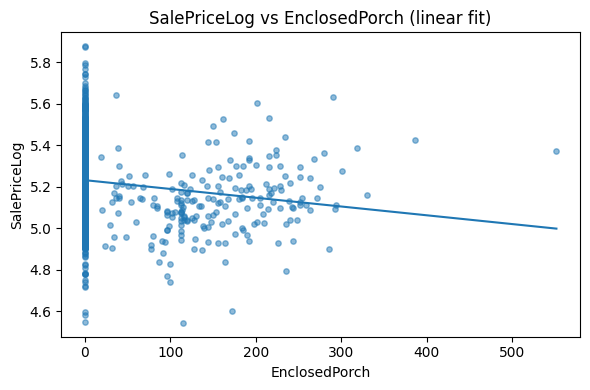

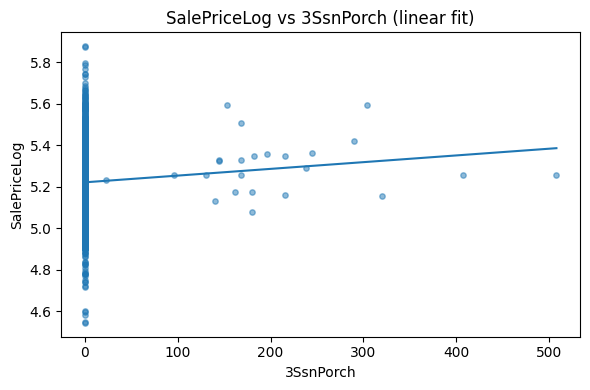

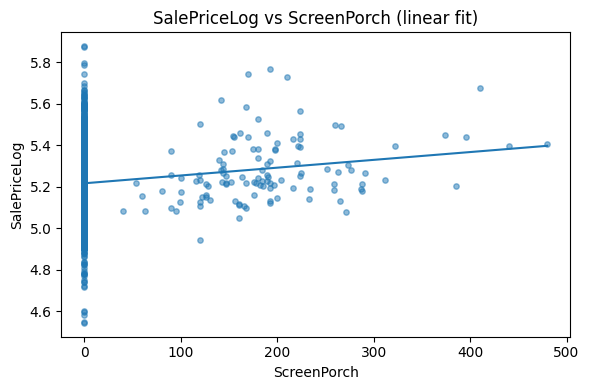

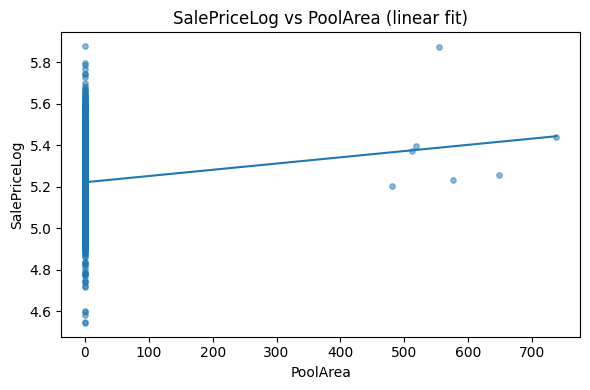

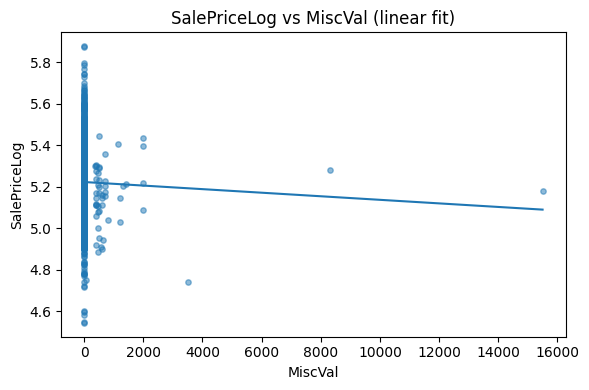

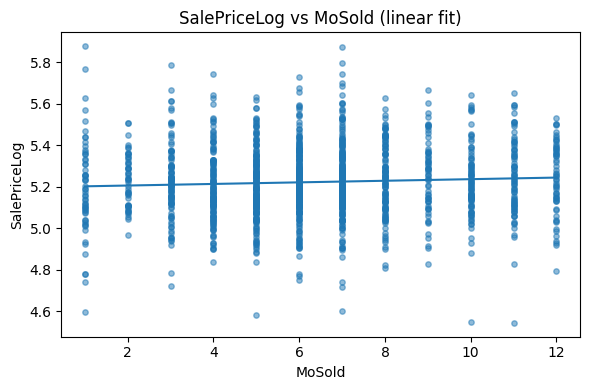

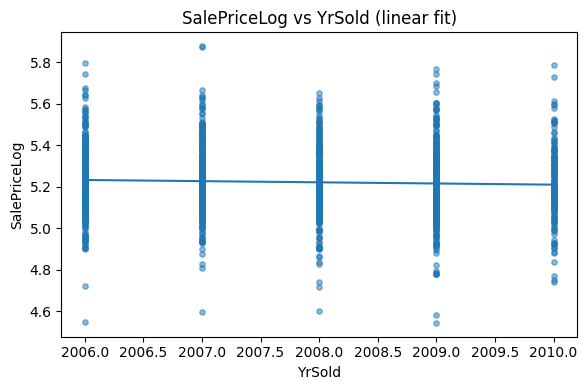

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ensure SalePriceLog exists
if "SalePriceLog" not in df_train_filled.columns:
    df_train_filled["SalePriceLog"] = np.log10(df_train_filled["SalePrice"])

# Relevant numerical variables: numeric columns excluding SalePrice and Id
num_cols = df_train_filled.select_dtypes(include=[np.number]).columns.tolist()
exclude = {"SalePrice", "SalePriceLog", "Id"}
features = [c for c in num_cols if c not in exclude]

y = df_train_filled["SalePriceLog"].values

for col in features:
    x = df_train_filled[col].values

    # Fit linear regression line y = a*x + b
    a, b = np.polyfit(x, y, 1)

    # Plot scatter + regression line
    plt.figure(figsize=(6, 4))
    plt.scatter(x, y, alpha=0.5, s=15)
    x_line = np.linspace(np.nanmin(x), np.nanmax(x), 200)
    plt.plot(x_line, a * x_line + b)

    plt.xlabel(col)
    plt.ylabel("SalePriceLog")
    plt.title(f"SalePriceLog vs {col} (linear fit)")
    plt.tight_layout()
    plt.show()


The numerical variable that seems to be the most linearly
correlated with SalePriceLog are the GarageArea, GarageYrBlt, GrLivArea, 1stFlrSf, YearBuilt and TotalBsmtSF variables.

### C.8


In [57]:
import numpy as np
import pandas as pd

# Ensure SalePriceLog exists
if "SalePriceLog" not in df_train_filled.columns:
    df_train_filled["SalePriceLog"] = np.log10(df_train_filled["SalePrice"])

# Numerical columns (exclude Id and raw SalePrice)
num_cols = df_train_filled.select_dtypes(include=[np.number]).columns
num_cols = [c for c in num_cols if c not in ["Id", "SalePrice"]]

# Correlation of each numeric feature with SalePriceLog
corr_with_target = df_train_filled[num_cols].corr()["SalePriceLog"].drop("SalePriceLog")

# Sort by absolute correlation (most predictive first)
corr_sorted = corr_with_target.reindex(corr_with_target.abs().sort_values(ascending=False).index)

print("Top correlations with SalePriceLog (sorted by |corr|):")
print(corr_sorted.head(15))

print("\nBottom correlations with SalePriceLog (sorted by |corr|):")
print(corr_sorted.tail(15))


Top correlations with SalePriceLog (sorted by |corr|):
OverallQual     0.817168
GrLivArea       0.700788
GarageCars      0.680871
GarageArea      0.650865
TotalBsmtSF     0.612439
1stFlrSF        0.597110
FullBath        0.593914
YearBuilt       0.590704
GarageYrBlt     0.572870
YearRemodAdd    0.567227
TotRmsAbvGrd    0.533599
Fireplaces      0.487622
MasVnrArea      0.426923
BsmtFinSF1      0.373768
WoodDeckSF      0.340497
Name: SalePriceLog, dtype: float64

Bottom correlations with SalePriceLog (sorted by |corr|):
BsmtUnfSF        0.220688
BedroomAbvGr     0.207278
EnclosedPorch   -0.149519
KitchenAbvGr    -0.147589
ScreenPorch      0.121397
MSSubClass      -0.071171
PoolArea         0.069965
MoSold           0.059762
3SsnPorch        0.054979
YrSold          -0.043084
OverallCond     -0.038592
LowQualFinSF    -0.038193
MiscVal         -0.024435
BsmtFinSF2       0.006421
BsmtHalfBath    -0.005377
Name: SalePriceLog, dtype: float64


The log transformation improves the interpretability of correlations by reducing skewness and outlier influence, leading to stronger and more linear relationships between SalePrice and key numerical predictors, without introducing spurious correlations.

### C.9


Categorical features least correlated with SalePriceLog:
Utilities       0.000161
LandSlope       0.001479
Street          0.003319
BsmtFinType2    0.007742
PoolQC          0.008189
MiscFeature     0.010747
Condition2      0.012126
RoofMatl        0.017996
LotConfig       0.023477
Functional      0.024504
dtype: float64


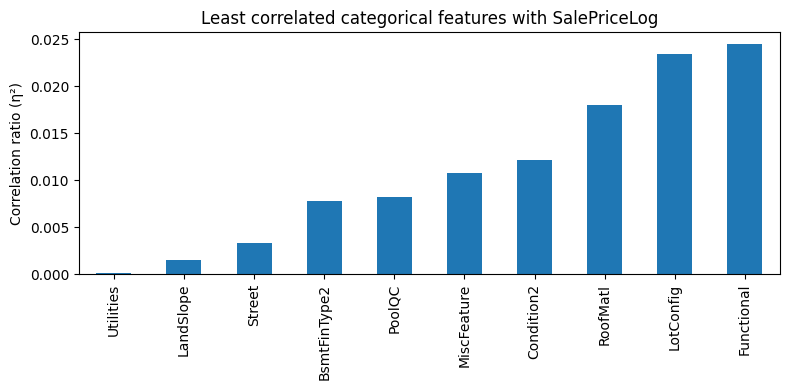

In [59]:
# Ensure SalePriceLog exists
if "SalePriceLog" not in df_train_filled.columns:
    df_train_filled["SalePriceLog"] = np.log10(df_train_filled["SalePrice"])

# Select categorical columns
cat_cols = df_train_filled.select_dtypes(exclude=[np.number]).columns.tolist()

# Compute correlation ratio between the categorical features and SalePriceLog
def correlation_ratio(categories, values):
    categories = pd.Series(categories)
    values = pd.Series(values)
    overall_mean = values.mean()
    ss_between = sum(
        len(values[categories == cat]) * (values[categories == cat].mean() - overall_mean) ** 2
        for cat in categories.dropna().unique()
    )
    ss_total = ((values - overall_mean) ** 2).sum()
    return ss_between / ss_total if ss_total > 0 else 0

cat_corr = {
    col: correlation_ratio(df_train_filled[col], df_train_filled["SalePriceLog"])
    for col in cat_cols
}

cat_corr_series = pd.Series(cat_corr).sort_values()

print("Categorical features least correlated with SalePriceLog:")
print(cat_corr_series.head(10))

# Bar plot for better visualization
plt.figure(figsize=(8, 4))
cat_corr_series.head(10).plot(kind="bar")
plt.ylabel("Correlation ratio (η²)")
plt.title("Least correlated categorical features with SalePriceLog")
plt.tight_layout()
plt.show()


Utilities seems to be the lest correlated

### C.10

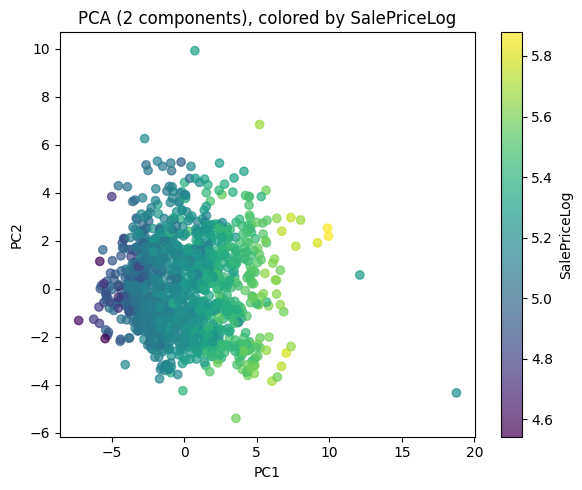

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Columns with no missing values
num_cols = df_train_filled.select_dtypes(include=[np.number]).columns.tolist()
exclude = {"Id", "SalePrice", "SalePriceLog"}
num_cols = [c for c in num_cols if c not in exclude]

df_pca = df_train_filled[num_cols].dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_pca)

#PCA with 2 components
pca2 = PCA(n_components=2)
X_pca2 = pca2.fit_transform(X_scaled)

#PCA with 3 components
pca3 = PCA(n_components=3)
X_pca3 = pca3.fit_transform(X_scaled)

# Color by SalePriceLog to see structure better
saleprice_log = df_train_filled.loc[df_pca.index, "SalePriceLog"]

# --- Visualization: first 2 principal components ---
plt.figure(figsize=(6, 5))
sc = plt.scatter(X_pca2[:, 0], X_pca2[:, 1],
                 c=saleprice_log, cmap="viridis", alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA (2 components), colored by SalePriceLog")
plt.colorbar(sc, label="SalePriceLog")
plt.tight_layout()
plt.show()


/tmp/ipython-input-2289558377.py:17: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


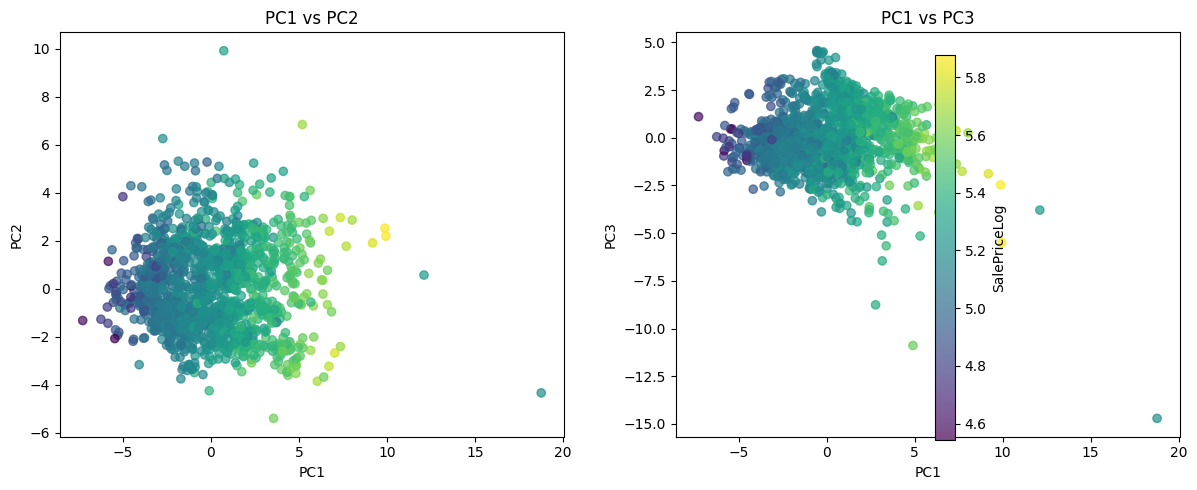

Explained variance ratio (2 PCs): [0.20039322 0.0894857 ]
Explained variance ratio (3 PCs): [0.20039322 0.0894857  0.07093865]


In [62]:

# Visualization: first 3 principal components (PC1 vs PC2, PC1 vs PC3) ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sc1 = axes[0].scatter(X_pca3[:, 0], X_pca3[:, 1],
                      c=saleprice_log, cmap="viridis", alpha=0.7)
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].set_title("PC1 vs PC2")

sc2 = axes[1].scatter(X_pca3[:, 0], X_pca3[:, 2],
                      c=saleprice_log, cmap="viridis", alpha=0.7)
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC3")
axes[1].set_title("PC1 vs PC3")

fig.colorbar(sc1, ax=axes, label="SalePriceLog")
plt.tight_layout()
plt.show()

# --- Explained variance ratios ---
print("Explained variance ratio (2 PCs):", pca2.explained_variance_ratio_)
print("Explained variance ratio (3 PCs):", pca3.explained_variance_ratio_)

###C.11

In [64]:
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import RidgeCV

# --- Load test set ---
df_test = pd.read_csv("house_test.csv")

# --- Target: log10(SalePrice) ---
y = np.log10(df_train["SalePrice"].values)

# --- Features: drop BOTH SalePrice and SalePriceLog from training features (if present) ---
X = df_train.drop(columns=["SalePrice", "SalePriceLog"], errors="ignore")
X_test = df_test.copy()

# --- Identify numeric/categorical columns from TRAIN only ---
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

# Remove Id from features if present (keep for output only)
if "Id" in num_cols:
    num_cols.remove("Id")
if "Id" in cat_cols:
    cat_cols.remove("Id")

# --- Preprocessing pipelines ---
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ],
    remainder="drop"
)

# --- Model: Ridge regression with CV over alphas ---
alphas = np.logspace(-3, 3, 50)
model = RidgeCV(alphas=alphas)

pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", model)
])

# --- Fit model ---
pipe.fit(X, y)

# --- Align test columns to train columns (prevents "missing columns" errors) ---
X_test_aligned = X_test.reindex(columns=X.columns)

# --- Predict and back-transform ---
y_pred_log = pipe.predict(X_test_aligned)
y_pred = 10 ** y_pred_log

# --- Output predictions ---
pred_df = pd.DataFrame({
    "Id": df_test["Id"] if "Id" in df_test.columns else np.arange(len(df_test)),
    "PredictedSalePrice": y_pred
})

print(pred_df)


    Id  PredictedSalePrice
0    1        92623.528384
1    2       127764.304039
2    3       252642.323656
3    4       126900.908426
4    5       119038.841277
5    6       203304.379532
6    7       175392.478692
7    8       206460.155133
8    9       245618.303078
9   10       147483.558820
10  11       145555.054418


## Problem D
### D.1

In [65]:
# Load dataset
df_air = pd.read_csv("AirQuality.csv", sep=";", decimal=",")

# Drop last two empty columns (known issue in this dataset)
df_air = df_air.dropna(axis=1, how="all")

# Replace -200 (missing value indicator) with NaN
df_air = df_air.replace(-200, np.nan)

# Display basic info
df_air.info()
df_air.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9471 entries, 0 to 9470
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   object 
 1   Time           9357 non-null   object 
 2   CO(GT)         7674 non-null   float64
 3   PT08.S1(CO)    8991 non-null   float64
 4   NMHC(GT)       914 non-null    float64
 5   C6H6(GT)       8991 non-null   float64
 6   PT08.S2(NMHC)  8991 non-null   float64
 7   NOx(GT)        7718 non-null   float64
 8   PT08.S3(NOx)   8991 non-null   float64
 9   NO2(GT)        7715 non-null   float64
 10  PT08.S4(NO2)   8991 non-null   float64
 11  PT08.S5(O3)    8991 non-null   float64
 12  T              8991 non-null   float64
 13  RH             8991 non-null   float64
 14  AH             8991 non-null   float64
dtypes: float64(13), object(2)
memory usage: 1.1+ MB


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


### D.2

In [66]:
target = "C6H6(GT)"

# Select relevant numerical sensor features
features = [
    "CO(GT)",
    "NMHC(GT)",
    "NOx(GT)",
    "NO2(GT)",
    "T",
    "RH",
    "AH"
]

X = df_air[features]
y = df_air[target]
